# Stroke Generation Model

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Sequence, List, Dict, Any
import os
from scipy import stats
import yaml

from dataclasses import dataclass, field
from scipy.special import erf
import torch
import torch.nn as nn
from torch.nn.init import xavier_uniform
import torch.nn.functional as F
from torch.distributions import Categorical, MultivariateNormal
from torch.utils.data import Dataset, DataLoader

ModuleNotFoundError: No module named 'torch'

## Stroke

In [8]:
STROKE_TIME_COLS = ['D', 'mu', 'sigma', 'to']
STROKE_GEOM_COLS = ['start_x', 'start_y', 'start_z', 
                    'mid_x', 'mid_y', 'mid_z', 
                    'end_x', 'end_y', 'end_z']
PERFORMANCE_COLS = ['snr_t', 'snr_v']
ROOT_TO_SAMPLE_DIRS = ['subject', 'task', 'recording', 'stroke_number']

COLLINEAR_TOL = 1e-6   # relative tolerance for the collinearity test
EPS = 1e-12

DEFAULT_COLS = {
    "D": "D",
    "mu": "mu",
    "sigma": "sigma",
    "t0": "t0",
    "start": ("start_x", "start_y", "start_z"),
    "mid": ("mid_x", "mid_y", "mid_z"),
    "end": ("end_x", "end_y", "end_z"),
}


def _unit(v: np.ndarray) -> np.ndarray:
    """Normalize vectors along the last axis; zero vectors stay zero."""
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > EPS, v / np.maximum(n, EPS), 0.0)


def direction_to_angles(d: np.ndarray) -> tuple[float, float]:
    """
    Convert a 3D direction into (theta, psi).

    theta: azimuth in the xy plane, atan2(dy, dx), in (-pi, pi]
    psi:   elevation from the xy plane, atan2(dz, hypot(dx, dy)), in [-pi/2, pi/2]

    Adapt this function if your framework defines psi differently
    (e.g. as a polar angle from the z axis).
    """
    d = np.asarray(d, dtype=float)
    theta = np.arctan2(d[1], d[0])
    psi = np.arctan2(d[2], np.hypot(d[0], d[1]))
    return float(theta), float(psi)


@dataclass(frozen=True)
class Arc:
    """Circular arc through start, mid, end (mid = point at half of the swept angle)."""
    start: np.ndarray
    end: np.ndarray
    center: np.ndarray | None   # None for a straight segment
    normal: np.ndarray | None   # unit normal; rotation start -> mid is positive about it
    radius: float               # np.inf for a straight segment
    total_angle: float          # Theta in (0, 2*pi); 0 for a straight segment

    @property
    def is_line(self) -> bool:
        return self.center is None

    @property
    def length(self) -> float:
        if self.is_line:
            return float(np.linalg.norm(self.end - self.start))
        return self.radius * self.total_angle

    @classmethod
    def from_three_points(cls, start, mid, end) -> "Arc":
        start, mid, end = (np.asarray(p, dtype=float) for p in (start, mid, end))
        u, v = mid - start, end - start
        w = np.cross(u, v)
        nu, nv, nw = np.linalg.norm(u), np.linalg.norm(v), np.linalg.norm(w)

        # Degenerate / collinear case -> straight segment
        if nu < EPS or nv < EPS or nw <= COLLINEAR_TOL * nu * nv:
            return cls(start, end, None, None, np.inf, 0.0)

        # Circumcenter of the three points (3D)
        center = start + (np.dot(v, v) * np.cross(w, u) + np.dot(u, u) * np.cross(v, w)) / (2.0 * nw**2)

        r_s, r_m = start - center, mid - center
        cross = np.cross(r_s, r_m)
        normal = cross / np.linalg.norm(cross)

        # mid is at half angle: Theta = 2 * angle(start -> mid), in (0, pi) for the half
        half = np.arctan2(np.linalg.norm(cross), np.dot(r_s, r_m))
        return cls(start, end, center, normal, float(np.linalg.norm(r_s)), float(2.0 * half))

    def point(self, delta) -> np.ndarray:
        """Points on the arc for progress delta in [0, 1]. Returns (N, 3)."""
        delta = np.atleast_1d(np.asarray(delta, dtype=float))
        if self.is_line:
            return self.start + delta[:, None] * (self.end - self.start)
        alpha = self.total_angle * delta
        r = self.start - self.center
        # Rodrigues rotation; n . r = 0 so the third term vanishes
        return (self.center
                + r[None, :] * np.cos(alpha)[:, None]
                + np.cross(self.normal, r)[None, :] * np.sin(alpha)[:, None])

    def tangent(self, delta) -> np.ndarray:
        """Unit tangent (direction of motion) for progress delta. Returns (N, 3)."""
        delta = np.atleast_1d(np.asarray(delta, dtype=float))
        if self.is_line:
            d = _unit(self.end - self.start)
            return np.tile(d, (delta.size, 1))
        alpha = self.total_angle * delta
        r = self.start - self.center
        # d/dalpha of the point = n x (p - c)
        t = (np.cross(self.normal, r)[None, :] * np.cos(alpha)[:, None]
             - r[None, :] * np.sin(alpha)[:, None])
        return _unit(t)

    def boundary_angles(self) -> dict[str, float]:
        """theta_0, psi_0 (start) and theta_e, psi_e (end) of the tangent direction."""
        t0, te = self.tangent(0.0)[0], self.tangent(1.0)[0]
        theta_0, psi_0 = direction_to_angles(t0)
        theta_e, psi_e = direction_to_angles(te)
        return {"theta_0": theta_0, "psi_0": psi_0, "theta_e": theta_e, "psi_e": psi_e}


@dataclass
class Stroke:
    D: float
    mu: float
    sigma: float
    t0: float
    start: np.ndarray
    mid: np.ndarray
    end: np.ndarray
    arc: Arc = field(init=False, repr=False)

    def __post_init__(self):
        self.start, self.mid, self.end = (np.asarray(p, dtype=float) for p in (self.start, self.mid, self.end))
        self.arc = Arc.from_three_points(self.start, self.mid, self.end)

    @classmethod
    def from_row(cls, row: pd.Series, cols: dict = DEFAULT_COLS) -> "Stroke":
        return cls(
            D=float(row[cols["D"]]),
            mu=float(row[cols["mu"]]),
            sigma=float(row[cols["sigma"]]),   # if the column stores exp(sigma), use np.log(...) here
            t0=float(row[cols["t0"]]),
            start=row[list(cols["start"])].to_numpy(dtype=float),
            mid=row[list(cols["mid"])].to_numpy(dtype=float),
            end=row[list(cols["end"])].to_numpy(dtype=float),
        )

    # ---- lognormal temporal profile -------------------------------------
    def speed(self, t) -> np.ndarray:
        """Scalar speed profile Lambda(t) * D."""
        tau = np.asarray(t, dtype=float) - self.t0
        valid = tau > 0
        tau_s = np.where(valid, tau, 1.0)
        v = (self.D / (self.sigma * np.sqrt(2 * np.pi) * tau_s)
             * np.exp(-(np.log(tau_s) - self.mu) ** 2 / (2 * self.sigma**2)))
        return np.where(valid, v, 0.0)

    def progress(self, t) -> np.ndarray:
        """Lognormal CDF: fraction of the arc covered, in [0, 1]."""
        tau = np.asarray(t, dtype=float) - self.t0
        valid = tau > 0
        tau_s = np.where(valid, tau, 1.0)
        delta = 0.5 * (1.0 + erf((np.log(tau_s) - self.mu) / (self.sigma * np.sqrt(2))))
        return np.where(valid, delta, 0.0)

    # ---- spatial contribution -------------------------------------------
    def displacement(self, t) -> np.ndarray:
        """Displacement w.r.t. the stroke start, shape (N, 3)."""
        return self.arc.point(self.progress(t)) - self.start

    def velocity(self, t) -> np.ndarray:
        """Vector velocity, shape (N, 3) (useful to validate against recorded data)."""
        delta = self.progress(t)
        return self.speed(t)[:, None] * self.arc.tangent(delta)

    def angles(self) -> dict[str, float]:
        return self.arc.boundary_angles()

    @property
    def arc_length(self) -> float:
        return self.arc.length

    @property
    def t_end(self) -> float:
        """Rough end of the stroke: exp(mu + 3 sigma) after t0."""
        return self.t0 + float(np.exp(self.mu + 3.0 * self.sigma))


def strokes_from_dataframe(df, subject, task, recording, cols: dict = DEFAULT_COLS) -> list[Stroke]:
    sel = df[(df["subject"] == subject) & (df["task"] == task) & (df["recording"] == recording)]
    sel = sel.sort_values("stroke_number")
    return [Stroke.from_row(row, cols) for _, row in sel.iterrows()]


def reconstruct_trajectory(strokes: list[Stroke], t, p0=None) -> np.ndarray:
    """Sum of the stroke displacements, shape (N, 3)."""
    t = np.asarray(t, dtype=float)
    p0 = strokes[0].start if p0 is None else np.asarray(p0, dtype=float)
    return p0 + sum(s.displacement(t) for s in strokes)

## Nework Architecture

### Mixture Density Network Head

In [9]:

class MixtureDensityNetwork(nn.Module):
    """
    MDN head with full-covariance Gaussian components.
    Outputs: means [B, K, D], lower Cholesky factors [B, K, D, D], mixing logits [B, K].
    """

    def __init__(self, input_dim, output_dim, num_components, hidden_dim=128, min_diag=1e-3):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.num_components = num_components
        self.hidden_dim = hidden_dim
        self.min_diag = min_diag
        self.num_tril = output_dim * (output_dim + 1) // 2

        rows, cols = torch.tril_indices(output_dim, output_dim)
        self.register_buffer("tril_rows", rows, persistent=False)
        self.register_buffer("tril_cols", cols, persistent=False)
        self.register_buffer("diag_mask", rows == cols, persistent=False)

        self.hidden_layer = nn.Linear(input_dim, hidden_dim)
        self.weights_layer = nn.Linear(hidden_dim, num_components)  # mixing logits
        self.means_layer = nn.Linear(hidden_dim, num_components * output_dim)
        self.scale_layer = nn.Linear(hidden_dim, num_components * self.num_tril)

    def set_weights(self, target_samples: torch.Tensor, sigma_weight_scale: float = 0.1):
        """
        Initialization. `target_samples` [N, D] should already be standardized.
        Means are spread over the target range; each Cholesky factor starts as
        diag(std_d) with zero off-diagonal entries.
        """
        nn.init.kaiming_uniform_(self.hidden_layer.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden_layer.bias)

        nn.init.xavier_uniform_(self.weights_layer.weight)
        nn.init.xavier_uniform_(self.means_layer.weight)
        nn.init.xavier_uniform_(self.scale_layer.weight)

        t_min = target_samples.min(dim=0).values  # [D]
        t_max = target_samples.max(dim=0).values  # [D]
        mean_bias = torch.empty(self.num_components, self.output_dim)
        for k in range(self.num_components):
            mean_bias[k] = (t_min + (t_max - t_min) * (k + 0.5) / self.num_components).cpu()

        with torch.no_grad():
            self.means_layer.bias.copy_(mean_bias.reshape(-1))
            self.scale_layer.weight.mul_(sigma_weight_scale)

            # inverse softplus so that diag(L) starts at the per-dimension data std
            data_std = target_samples.std(dim=0).to(self.scale_layer.bias)
            init_diag = (data_std - self.min_diag).clamp_min(1e-3)
            raw_diag = torch.log(torch.expm1(init_diag))
            bias = torch.zeros(self.num_components, self.num_tril).to(self.scale_layer.bias)
            bias[:, self.diag_mask] = raw_diag
            self.scale_layer.bias.copy_(bias.reshape(-1))

    def _build_scale_tril(self, raw: torch.Tensor) -> torch.Tensor:
        """raw [B, K, m] -> lower-triangular L [B, K, D, D] with positive diagonal."""
        batch = raw.size(0)
        dim = self.output_dim
        tril = raw.new_zeros(batch, self.num_components, dim, dim)
        tril[..., self.tril_rows, self.tril_cols] = raw
        diag = F.softplus(tril.diagonal(dim1=-2, dim2=-1)) + self.min_diag
        return tril.tril(-1) + torch.diag_embed(diag)

    def forward(self, x: torch.Tensor):
        hidden = torch.relu(self.hidden_layer(x))
        mix_logits = self.weights_layer(hidden)
        means = self.means_layer(hidden).view(-1, self.num_components, self.output_dim)
        raw = self.scale_layer(hidden).view(-1, self.num_components, self.num_tril)
        return means, self._build_scale_tril(raw), mix_logits

NameError: name 'nn' is not defined

### Full Model Architecture

In [10]:
class GenerativeModel(nn.Module):
    """Generative model of strokes: embeddings -> LSTM -> trunk -> full-covariance MDN."""

    def __init__(self, input_dim, embedding_dim, LSTM_dim, LSTM_count, output_dim,
                 mixture_components, recur_dim=None, min_diag=1e-3):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.embedding_dim = embedding_dim
        self.lstm_dim = LSTM_dim
        self.lstm_count = LSTM_count
        self.mixture_components = mixture_components
        # dimension of the previous-step vector (defaults to the target dimension)
        self.recur_dim = output_dim if recur_dim is None else recur_dim

        self.input_embedding = nn.Linear(input_dim, embedding_dim)
        self.recur_embedding = nn.Linear(self.recur_dim, embedding_dim)
        self.lstm = nn.LSTM(input_size=embedding_dim * 2, hidden_size=LSTM_dim,
                            num_layers=LSTM_count, batch_first=True)
        self.trunk = nn.Linear(LSTM_dim, LSTM_dim)
        self.mdn = MixtureDensityNetwork(LSTM_dim, output_dim,
                                         num_components=mixture_components, min_diag=min_diag)

    def set_weights(self, target_samples, sigma_weight_scale=0.1):
        self.mdn.set_weights(target_samples, sigma_weight_scale)
        for layer in (self.input_embedding, self.recur_embedding, self.trunk):
            nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
            nn.init.zeros_(layer.bias)

    def forward(self, x, prev_output=None, state=None, return_state=False):
        """
        Args:
            x: conditioning input [B, input_dim]
            prev_output: previous-step vector [B, recur_dim] (zeros embedding if None)
            state: optional LSTM state (h, c) carried across calls; None resets it
        Returns:
            means [B, K, D], scale_tril [B, K, D, D], mix_logits [B, K] (+ state if requested)
        """
        input_embedded = self.input_embedding(x)
        if prev_output is not None:
            prev_embedded = self.recur_embedding(prev_output)
        else:
            prev_embedded = torch.zeros_like(input_embedded)

        combined = torch.cat((input_embedded, prev_embedded), dim=-1)
        lstm_out, new_state = self.lstm(combined.unsqueeze(1), state)  # sequence length 1
        trunk_out = torch.relu(self.trunk(lstm_out.squeeze(1)))

        means, scale_tril, mix_logits = self.mdn(trunk_out)
        if return_state:
            return means, scale_tril, mix_logits, new_state
        return means, scale_tril, mix_logits

    @torch.no_grad()
    def sample(self, x, prev_output=None, state=None):
        means, scale_tril, mix_logits = self.forward(x, prev_output, state)
        batch_idx = torch.arange(means.size(0), device=means.device)
        comp_idx = Categorical(logits=mix_logits).sample()
        sel_mean = means[batch_idx, comp_idx]          # [B, D]
        sel_tril = scale_tril[batch_idx, comp_idx]     # [B, D, D]
        eps = torch.randn_like(sel_mean)
        return sel_mean + (sel_tril @ eps.unsqueeze(-1)).squeeze(-1)



NameError: name 'nn' is not defined

## Loss

In [11]:
def duplication_matrix(dim: int, device=None, dtype=None) -> torch.Tensor:
    """
    Duplication matrix Dup such that vec(S) = Dup @ vech(S) for any symmetric S.
    Shape: [dim * dim, dim * (dim + 1) // 2]. Row-major vec, lower-triangle vech.
    """
    rows, cols = torch.tril_indices(dim, dim, device=device)
    n_free = rows.numel()
    dup = torch.zeros(dim * dim, n_free, device=device, dtype=dtype)
    col_idx = torch.arange(n_free, device=device)
    dup[rows * dim + cols, col_idx] = 1.0
    dup[cols * dim + rows, col_idx] = 1.0
    return dup


def gaussian_fisher(sigma: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Explicit Fisher information blocks of N(mu, Sigma).

    Args:
        sigma: covariance matrices, shape [..., D, D].
    Returns:
        fisher_mu:    [..., D, D]   = Sigma^-1
        fisher_sigma: [..., m, m]   = 1/2 Dup^T (Sigma^-1 (x) Sigma^-1) Dup, m = D(D+1)/2
    """
    dim = sigma.size(-1)
    dup = duplication_matrix(dim, sigma.device, sigma.dtype)
    sigma_inv = torch.linalg.inv(sigma)
    kron = torch.einsum("...ij,...kl->...ikjl", sigma_inv, sigma_inv)
    kron = kron.reshape(*sigma.shape[:-2], dim * dim, dim * dim)
    fisher_sigma = 0.5 * dup.T @ kron @ dup
    return sigma_inv, fisher_sigma


def gaussian_fisher_matrix(sigma: torch.Tensor) -> torch.Tensor:
    """Full block-diagonal Fisher matrix over (mu, vech(Sigma)), shape [..., D+m, D+m]."""
    fisher_mu, fisher_sigma = gaussian_fisher(sigma)
    dim, n_free = fisher_mu.size(-1), fisher_sigma.size(-1)
    full = sigma.new_zeros(*sigma.shape[:-2], dim + n_free, dim + n_free)
    full[..., :dim, :dim] = fisher_mu
    full[..., dim:, dim:] = fisher_sigma
    return full


def gaussian_natural_gradient(
    diff: torch.Tensor,
    sigma: torch.Tensor,
    resp: torch.Tensor,
    explicit_fisher: bool = False,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Complete-data natural gradient of resp * log N(y; mu, Sigma) w.r.t. (mu, vech(Sigma)).

    Args:
        diff:  y - mu, shape [..., D]
        sigma: covariance, shape [..., D, D]
        resp:  responsibilities, shape [...]
        explicit_fisher: if True, build the Fisher blocks explicitly and solve F x = grad
            (O(D^6) per component: use it to validate, not for training).
            If False, use the equivalent closed form.
    Returns:
        nat_mu:    [..., D]
        nat_sigma: [..., m]  (vech coordinates)
    """
    dim = diff.size(-1)
    rows, cols = torch.tril_indices(dim, dim, device=diff.device)
    outer = diff.unsqueeze(-1) * diff.unsqueeze(-2)  # d d^T

    if not explicit_fisher:
        nat_mu = resp.unsqueeze(-1) * diff
        nat_sigma = resp[..., None, None] * (outer - sigma)
        return nat_mu, nat_sigma[..., rows, cols]

    fisher_mu, fisher_sigma = gaussian_fisher(sigma)
    sigma_inv = fisher_mu
    dup = duplication_matrix(dim, diff.device, diff.dtype)

    grad_mu = resp.unsqueeze(-1) * (sigma_inv @ diff.unsqueeze(-1)).squeeze(-1)
    # symmetric matrix derivative of resp * log N w.r.t. Sigma
    grad_mat = 0.5 * resp[..., None, None] * (sigma_inv @ outer @ sigma_inv - sigma_inv)
    grad_vech = torch.einsum("pm,...p->...m", dup, grad_mat.reshape(*sigma.shape[:-2], dim * dim))

    nat_mu = torch.linalg.solve(fisher_mu, grad_mu.unsqueeze(-1)).squeeze(-1)
    nat_sigma = torch.linalg.solve(fisher_sigma, grad_vech.unsqueeze(-1)).squeeze(-1)
    return nat_mu, nat_sigma


def categorical_natural_gradient(
    resp: torch.Tensor, pi: torch.Tensor, pi_floor: float = 1e-4
) -> torch.Tensor:
    """
    Natural gradient of sum_k r_k log pi_k w.r.t. the softmax logits.
    The Fisher matrix diag(pi) - pi pi^T is singular; r / pi solves F x = r - pi, and the
    mean is removed (softmax is invariant to a constant shift of the logits).
    `pi_floor` avoids huge steps when a component has a vanishing weight.
    """
    ratio = resp / pi.clamp_min(pi_floor)
    return ratio - ratio.mean(dim=-1, keepdim=True)

NameError: name 'torch' is not defined

In [12]:
def ngem_loss(
    model,
    batch,
    device,
    fisher_mode: str = "closed_form",
    natural_mixing: bool = True,
    pi_floor: float = 1e-4,
    return_nll: bool = False,
):
    """
    Multivariate (full covariance) nGEM surrogate loss.

    E-step: responsibilities from the current parameters (no gradient).
    M-step: the complete-data natural gradient w.r.t. the network outputs
            (means, vech(Sigma), mixing logits) is computed with the Fisher blocks of
            each component and injected into backprop through a surrogate loss, so that
            d(loss)/d(output) = -natural_gradient / batch_size.

    Args:
        fisher_mode: "closed_form" (fast) or "explicit" (builds and solves the Fisher
            blocks; use it for validation).
        natural_mixing: natural gradient for the mixing logits (True) or plain gradient
            r - pi (False).
        pi_floor: lower clamp on pi in the categorical natural gradient.
        return_nll: also return the mixture NLL (detached) for monitoring.
    """
    if fisher_mode not in ("closed_form", "explicit"):
        raise ValueError("fisher_mode must be 'closed_form' or 'explicit'")

    wp = batch["wp"].to(device)
    wp_n = batch["wp_n"].to(device)
    prev_t0 = batch["prev_t0"].to(device)
    prev_mu = batch["prev_mu"].to(device)
    prev_sigma = batch["prev_sigma"].to(device)
    prev_theta = batch["prev_theta"].to(device)
    prev_psi = batch["prev_psi"].to(device)
    t0 = batch["t0"].to(device)
    mu = batch["mu"].to(device)
    sigma = batch["sigma"].to(device)

    # target vector [B, D]
    target = torch.cat([t0, mu, sigma, batch["p_m"].to(device), batch["p_e"].to(device)], dim=-1)
    input_data = torch.cat([wp, wp_n], dim=-1)
    prev_input = torch.cat([prev_t0, prev_mu, prev_sigma, prev_theta, prev_psi], dim=-1)

    means, scale_tril, mix_logits = model(input_data, prev_output=prev_input)
    batch_size, dim = target.shape

    # ---- E-step (no gradient) ----
    with torch.no_grad():
        dist = MultivariateNormal(loc=means.detach(), scale_tril=scale_tril.detach())
        log_prob = dist.log_prob(target.unsqueeze(1))                  # [B, K]
        log_joint = F.log_softmax(mix_logits.detach(), dim=-1) + log_prob
        resp = torch.softmax(log_joint, dim=-1)                        # [B, K]
        nll = -torch.logsumexp(log_joint, dim=-1).mean()
        pi = torch.softmax(mix_logits.detach(), dim=-1)

    # ---- M-step: natural gradients w.r.t. the network outputs ----
    diff = (target.unsqueeze(1) - means).detach()                      # [B, K, D]
    cov = scale_tril @ scale_tril.transpose(-1, -2)                    # Sigma = L L^T (with grad)
    rows, cols = torch.tril_indices(dim, dim, device=target.device)
    cov_vech = cov[..., rows, cols]                                    # [B, K, m]

    nat_mu, nat_cov = gaussian_natural_gradient(
        diff, cov.detach(), resp, explicit_fisher=(fisher_mode == "explicit")
    )
    nat_pi = categorical_natural_gradient(resp, pi, pi_floor) if natural_mixing else resp - pi

    # Surrogate: its gradient w.r.t. (means, vech(Sigma), logits) is minus the natural
    # gradient; autograd then applies the Jacobian (chain rule) down to the weights.
    # Note: vech coordinates (lower triangle only) are used on purpose, so that the
    # off-diagonal entries of Sigma are not counted twice.
    surrogate = (
        (means * nat_mu).sum()
        + (cov_vech * nat_cov).sum()
        + (mix_logits * nat_pi).sum()
    )
    loss = -surrogate / batch_size

    if return_nll:
        return loss, nll
    return loss



### Dataset

In [13]:
class StrokeDataset(Dataset):
    """
    A custom dataset class for loading stroke data from a pandas DataFrame
    """
    def __init__(self, data_frame: pd.DataFrame):
        """
        Args:
            data_frame (pd.DataFrame): The DataFrame containing the stroke data.
        """
        self.data_frame = data_frame

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        return {
            'wp': torch.tensor(self.data_frame.iloc[idx]['wp'], dtype=torch.float32),
            'wp_n': torch.tensor(self.data_frame.iloc[idx]['wp_n'], dtype=torch.float32),
            'prev_t0': torch.tensor(self.data_frame.iloc[idx]['prev_t0'], dtype=torch.float32),
            'prev_mu': torch.tensor(self.data_frame.iloc[idx]['prev_mu'], dtype=torch.float32),
            'prev_sigma': torch.tensor(self.data_frame.iloc[idx]['prev_sigma'], dtype=torch.float32),
            'prev_theta': torch.tensor(self.data_frame.iloc[idx]['prev_theta'], dtype=torch.float32),
            'prev_psi': torch.tensor(self.data_frame.iloc[idx]['prev_psi'], dtype=torch.float32),
            't0': torch.tensor(self.data_frame.iloc[idx]['t0'], dtype=torch.float32),
            'mu': torch.tensor(self.data_frame.iloc[idx]['mu'], dtype=torch.float32),
            'sigma': torch.tensor(self.data_frame.iloc[idx]['sigma'], dtype=torch.float32),
            'p_m': torch.tensor(self.data_frame.iloc[idx]['p_m'], dtype=torch.float32),
            'p_e': torch.tensor(self.data_frame.iloc[idx]['p_e'], dtype=torch.float32)
        }

NameError: name 'Dataset' is not defined

In [14]:
class StrokeDataLoader(DataLoader):
    """
    A custom DataLoader class for loading stroke data.
    """
    def __init__(self, dataset: StrokeDataset, batch_size: int = 32, shuffle: bool = True, num_workers: int = 0):
        """
        Args:
            dataset (StrokeDataset): The dataset to load.
            batch_size (int): Number of samples per batch.
            shuffle (bool): Whether to shuffle the data at every epoch.
            num_workers (int): How many subprocesses to use for data loading.
        """
        super(StrokeDataLoader, self).__init__(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)

NameError: name 'DataLoader' is not defined

In [15]:
def create_database(root:str) -> pd.DataFrame:
    """
    Create a database of stroke parameters from CSV files in the given root directory.

    Args:
        root (str): The root directory containing CSV files.
    Returns:
        database (pd.DataFrame): Dafaframe representation of the dataset
    """
    root_folder = os.path.abspath(os.path.join(os.getcwd(), root))
    records = []

    for subject_folder in os.listdir(root_folder):
        if not os.path.isdir(os.path.join(root_folder, subject_folder)):
            continue
        subject_name = os.path.basename(subject_folder)

        for task_folder in os.listdir(os.path.join(root_folder, subject_folder)):
            if not os.path.isdir(os.path.join(root_folder, subject_folder, task_folder)):
                continue
            task_name = os.path.basename(task_folder)

            for csv_file in os.listdir(os.path.join(root_folder, subject_folder, task_folder)):
                if os.path.isdir(os.path.join(root_folder, subject_folder, task_folder, csv_file)):
                    continue
                if csv_file.endswith('logn.csv'):
                    
                    csv_path = os.path.join(root_folder, subject_folder, task_folder, csv_file)
                    recording_number = int(os.path.basename(csv_file).split('_')[1])
                    stroke_data = pd.read_csv(csv_path)

                    for _, row in stroke_data.iterrows():
                        record = {
                            'subject': subject_name,
                            'task': task_name,
                            'recording': recording_number,
                            'stroke_number': int(row['stroke']),
                        }
                        for col in STROKE_TIME_COLS + STROKE_GEOM_COLS + PERFORMANCE_COLS:
                            record[col] = row[col]

                        records.append(record)
            

    return pd.DataFrame(records)

Sample trajectory: subject=LUCIA_DE_LUCIA, task=BURST1_XY, recording=10


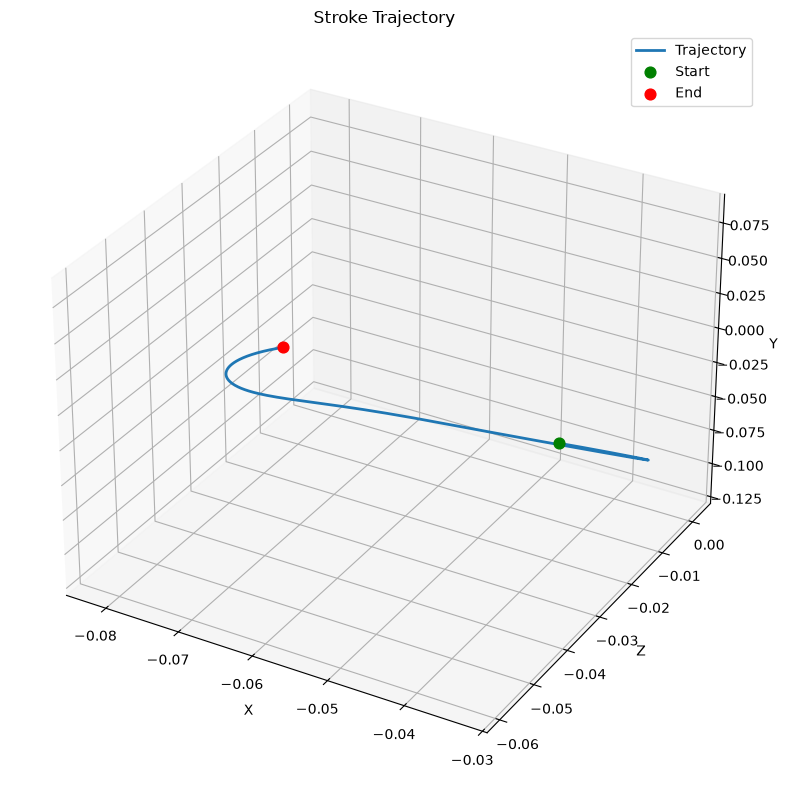

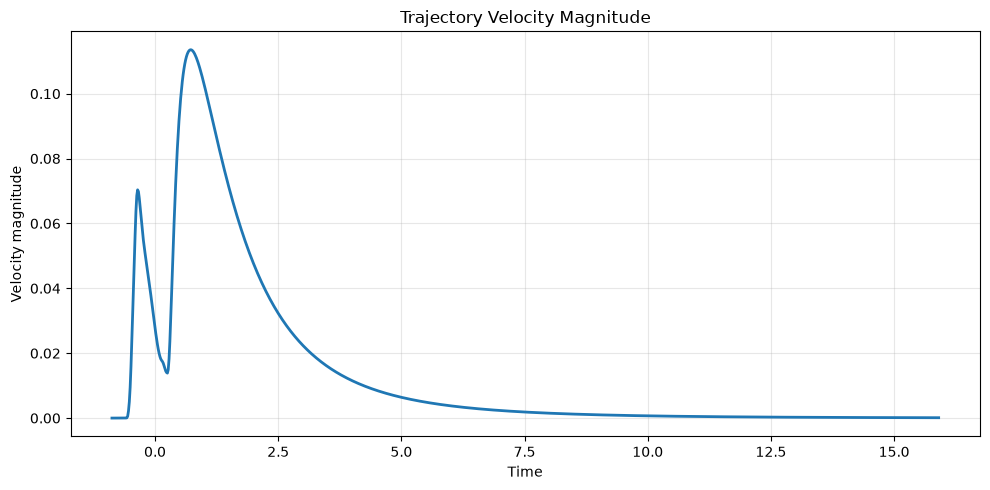

In [ ]:
database = create_database(os.path.join(os.getcwd(), '..', '..', '..', '..', 'lognormal_database'))
#database['sigma'] = np.exp(database['sigma'])
database = database.rename(columns={"to": "t0"})

random_seed = 40
np.random.seed(random_seed)
sample_index = np.random.choice(database.index)
sample_trajectory_subject, sample_trajectory_task, sample_trajectory_recording = database.iloc[sample_index][['subject', 'task', 'recording']]
print(f"Sample trajectory: subject={sample_trajectory_subject}, task={sample_trajectory_task}, recording={sample_trajectory_recording}")
sample_strokes = strokes_from_dataframe(database, sample_trajectory_subject, sample_trajectory_task, sample_trajectory_recording)
trajectory_times = np.linspace(sample_strokes[0].t0, sample_strokes[-1].t_end, 1000)
trajectory_positions = reconstruct_trajectory(sample_strokes, trajectory_times)
swap_axes = [0, 2, 1]  # Swap Y and Z axes for visualization
trajectory_positions = trajectory_positions[:, swap_axes]
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")


ax.plot(
    trajectory_positions[:, 0],
    trajectory_positions[:, 1],
    trajectory_positions[:, 2],
    linewidth=2,
    label="Trajectory",
)

ax.scatter(*trajectory_positions[0], color="green", s=60, label="Start")
ax.scatter(*trajectory_positions[-1], color="red", s=60, label="End")

ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_zlabel("Y")
ax.set_title("Stroke Trajectory")
ax.legend()
plt.tight_layout()
plt.show()

# Compute the total velocity vector and its magnitude
trajectory_velocity = sum(
    stroke.velocity(trajectory_times)
    for stroke in sample_strokes
)

velocity_magnitude = np.linalg.norm(trajectory_velocity, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trajectory_times, velocity_magnitude, linewidth=2)
ax.set_xlabel("Time")
ax.set_ylabel("Velocity magnitude")
ax.set_title("Trajectory Velocity Magnitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
coupled_database = database.merge(
    database,
    on=['subject', 'task', 'recording'],
    how='inner',
    suffixes=('', '_previous')
)
coupled_database = coupled_database[coupled_database['stroke_number'] == coupled_database['stroke_number_previous'] - 1]
coupled_database.head(10)

,subject,task,recording,stroke_number,D,mu,sigma,t0,start_x,start_y,...,start_y_previous,start_z_previous,mid_x_previous,mid_y_previous,mid_z_previous,end_x_previous,end_y_previous,end_z_previous,snr_t_previous,snr_v_previous
1,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,3,1,1.063957e-01,0.077771,0.984054,-0.877,0.004996,-0.037872,...,-0.011731,-0.013680,-0.044537,-0.010854,0.001303,0.001954,-0.038112,-0.006315,20.321446,19.852506
7,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,3,2,1.858216e-01,0.074381,1.192508,-0.647,0.067345,-0.011731,...,-0.038112,-0.006315,0.002418,-0.037879,-0.006489,0.005049,-0.037845,-0.002910,20.321446,19.852506
13,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,3,3,6.280231e-03,0.109357,1.140357,-0.282,0.001954,-0.038112,...,-0.037845,-0.002910,0.060571,-0.030096,-0.009061,0.010398,0.014970,-0.011937,20.321446,19.852506
19,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,3,4,1.575419e-01,0.071818,0.990777,0.116,0.005049,-0.037845,...,0.014970,-0.011937,-0.029803,-0.021738,-0.000004,0.001932,-0.037971,-0.006031,20.321446,19.852506
26,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,11,1,7.218063e-07,0.020949,1.178709,-0.877,-0.006576,-0.031098,...,-0.031098,-0.005257,-0.006576,-0.031098,-0.005257,-0.001775,-0.031641,-0.005864,22.820879,18.047062
41,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,11,2,5.158829e-03,0.019346,1.028931,-0.783,-0.006577,-0.031098,...,-0.031641,-0.005864,0.007790,-0.032259,-0.006775,0.071546,-0.012527,-0.013468,22.820879,18.047062
56,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,11,3,7.785029e-02,0.010035,0.943784,-0.737,-0.001775,-0.031641,...,-0.012527,-0.013468,0.003719,0.047796,-0.007305,-0.080634,-0.008824,-0.007316,22.820879,18.047062
71,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,11,4,2.074575e-01,0.024356,1.178365,-0.693,0.071546,-0.012527,...,-0.008824,-0.007316,-0.018317,-0.041065,-0.012905,-0.000590,-0.039110,-0.014898,22.820879,18.047062
86,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,11,5,9.102834e-02,0.044196,1.130160,-0.608,-0.080634,-0.008824,...,-0.039110,-0.014898,-0.000214,-0.039070,-0.014946,-0.000191,-0.039068,-0.014960,22.820879,18.047062
101,LUCIA_DE_LUCIA,GEOMETRIC6_ELLIPSE_XY,11,6,4.168285e-04,0.092146,1.045235,-0.350,-0.000590,-0.039110,...,-0.039068,-0.014960,-0.000170,-0.039063,-0.014956,-0.000181,-0.039067,-0.014966,22.820879,18.047062


In [17]:
current_start = coupled_database[['start_x', 'start_y', 'start_z']].to_numpy(dtype=np.float32)
previous_end = coupled_database[['end_x_previous', 'end_y_previous', 'end_z_previous']].to_numpy(dtype=np.float32)
distances = np.linalg.norm(current_start - previous_end, axis=1)

mean_distance = distances.mean()
std_distance = distances.std()

print(f"Mean distance: {mean_distance:.6f}")
print(f"Standard deviation: {std_distance:.6f}")

Mean distance: 0.070775
Standard deviation: 0.059881


In [18]:
coupled_database[['stroke_number', 'stroke_number_previous']].head(100)
filtered_coupled_database = coupled_database[coupled_database['D'] > 0.05]
print(f"Filtered coupled database length: {len(filtered_coupled_database)}, out of {len(coupled_database)} total coupled strokes.")
filtered_coupled_database[['stroke_number', 'stroke_number_previous']].head(10)

Filtered coupled database length: 2963, out of 5866 total coupled strokes.


,stroke_number,stroke_number_previous
1,1,2
7,2,3
19,4,5
56,3,4
71,4,5
86,5,6
176,11,12
191,12,13
526,9,10
564,10,11


In [19]:
PATH_TO_PATHS_FILE = os.path.join(os.getcwd(), '..', '..', '..', 'unisa_acg_ros2', 'haptics', 'haptic_interaction_teach_and_record_demo', 'config', 'paths.yaml')
if not os.path.exists(PATH_TO_PATHS_FILE):
    raise FileNotFoundError(f"Paths file not found: {PATH_TO_PATHS_FILE}")

WAYPOINTS_BY_TASK = {}
with open(PATH_TO_PATHS_FILE, 'r') as f:
    paths_data = yaml.safe_load(f)
    print(f"Loaded paths data: {paths_data['paths']}")
    for path in paths_data['paths']:
        WAYPOINTS_BY_TASK[path['name']] = path['waypoints']

WAYPOINTS_BY_TASK

Loaded paths data: [{'name': 'BURSTs_XY', 'waypoints': [{'x': 0.2, 'y': 0.2, 'z': 0.5}, {'x': 0.8, 'y': 0.8, 'z': 0.5}]}, {'name': 'BURSTs_XZ', 'waypoints': [{'x': 0.2, 'y': 0.5, 'z': 0.2}, {'x': 0.8, 'y': 0.5, 'z': 0.8}]}, {'name': 'BURSTs_YZ', 'waypoints': [{'x': 0.5, 'y': 0.2, 'z': 0.2}, {'x': 0.5, 'y': 0.8, 'z': 0.8}]}, {'name': 'BURSTc_XY', 'waypoints': [{'x': 0.1, 'y': 0.2, 'z': 0.5}, {'x': 0.9, 'y': 0.5, 'z': 0.5}, {'x': 0.1, 'y': 0.8, 'z': 0.5}]}, {'name': 'BURSTc_XZ', 'waypoints': [{'x': 0.2, 'y': 0.5, 'z': 0.1}, {'x': 0.5, 'y': 0.5, 'z': 0.9}, {'x': 0.8, 'y': 0.5, 'z': 0.1}]}, {'name': 'BURSTc_YZ', 'waypoints': [{'x': 0.5, 'y': 0.1, 'z': 0.2}, {'x': 0.5, 'y': 0.9, 'z': 0.5}, {'x': 0.5, 'y': 0.1, 'z': 0.8}]}, {'name': 'REVERSAL_X', 'waypoints': [{'x': 0.15, 'y': 0.5, 'z': 0.5}, {'x': 0.85, 'y': 0.5, 'z': 0.5}, {'x': 0.15, 'y': 0.55, 'z': 0.5}]}, {'name': 'REVERSAL_Z', 'waypoints': [{'x': 0.5, 'y': 0.5, 'z': 0.15}, {'x': 0.5, 'y': 0.5, 'z': 0.85}, {'x': 0.55, 'y': 0.5, 'z': 0.1

{'BURSTs_XY': [{'x': 0.2, 'y': 0.2, 'z': 0.5}, {'x': 0.8, 'y': 0.8, 'z': 0.5}],
 'BURSTs_XZ': [{'x': 0.2, 'y': 0.5, 'z': 0.2}, {'x': 0.8, 'y': 0.5, 'z': 0.8}],
 'BURSTs_YZ': [{'x': 0.5, 'y': 0.2, 'z': 0.2}, {'x': 0.5, 'y': 0.8, 'z': 0.8}],
 'BURSTc_XY': [{'x': 0.1, 'y': 0.2, 'z': 0.5},
  {'x': 0.9, 'y': 0.5, 'z': 0.5},
  {'x': 0.1, 'y': 0.8, 'z': 0.5}],
 'BURSTc_XZ': [{'x': 0.2, 'y': 0.5, 'z': 0.1},
  {'x': 0.5, 'y': 0.5, 'z': 0.9},
  {'x': 0.8, 'y': 0.5, 'z': 0.1}],
 'BURSTc_YZ': [{'x': 0.5, 'y': 0.1, 'z': 0.2},
  {'x': 0.5, 'y': 0.9, 'z': 0.5},
  {'x': 0.5, 'y': 0.1, 'z': 0.8}],
 'REVERSAL_X': [{'x': 0.15, 'y': 0.5, 'z': 0.5},
  {'x': 0.85, 'y': 0.5, 'z': 0.5},
  {'x': 0.15, 'y': 0.55, 'z': 0.5}],
 'REVERSAL_Z': [{'x': 0.5, 'y': 0.5, 'z': 0.15},
  {'x': 0.5, 'y': 0.5, 'z': 0.85},
  {'x': 0.55, 'y': 0.5, 'z': 0.15}],
 'REVERSAL_3D': [{'x': 0.15, 'y': 0.2, 'z': 0.3},
  {'x': 0.85, 'y': 0.8, 'z': 0.7},
  {'x': 0.25, 'y': 0.75, 'z': 0.35}],
 'CHECK_XY': [{'x': 0.15, 'y': 0.5, 'z': 0.5},


In [ ]:
def closest_waypoint_couple(stroke_start, stroke_end, waypoints):
    """
    Find the closest pair of waypoints to the stroke start and end points.

    Args:
        stroke_start (np.ndarray): The start point of the stroke (3D).
        stroke_end (np.ndarray): The end point of the stroke (3D).
        waypoints (list): List of waypoints, each waypoint is a dict with 'position' key.

    Returns:
        tuple: A tuple containing the closest start waypoint and closest end waypoint.
    """
    min_start_distance = float('inf')
    min_end_distance = float('inf')
    closest_start_wp = None
    closest_end_wp = None

    for index, wp in enumerate(waypoints):
        wp_position = np.array(wp['position'], dtype=np.float32)
        start_distance = np.linalg.norm(stroke_start - wp_position)
        end_distance = np.linalg.norm(stroke_end - wp_position)

        if start_distance < min_start_distance:
            min_start_distance = start_distance
            closest_start_wp = index

        if end_distance < min_end_distance:
            min_end_distance = end_distance
            closest_end_wp = index

    return closest_start_wp, closest_end_wp

In [21]:
filtered_coupled_database = filtered_coupled_database.copy()

filtered_coupled_database[
    ["closest_start_waypoint", "closest_end_waypoint"]
] = filtered_coupled_database.apply(
    lambda row: closest_waypoint_couple(
        np.array([row["start_x"], row["start_y"], row["start_z"]], dtype=np.float32),
        np.array([row["end_x"], row["end_y"], row["end_z"]], dtype=np.float32),
        WAYPOINTS_BY_TASK[row["task"]],
    ),
    axis=1,
    result_type="expand",
)

data = filtered_coupled_database.reset_index(drop=True).copy()

data = filtered_coupled_database.reset_index(drop=True).copy()

def vectors(frame, columns):
    return frame[columns].to_numpy(dtype=np.float32)

current_start = vectors(data, ["start_x", "start_y", "start_z"])
current_mid = vectors(data, ["mid_x", "mid_y", "mid_z"])
current_end = vectors(data, ["end_x", "end_y", "end_z"])

previous_start = vectors(data, ["start_x_previous", "start_y_previous", "start_z_previous"])
previous_mid = vectors(data, ["mid_x_previous", "mid_y_previous", "mid_z_previous"])
previous_end = vectors(data, ["end_x_previous", "end_y_previous", "end_z_previous"])


def entry_angles(p_start, p_mid, p_end) -> tuple[float, float]:
    """(theta, psi) of the direction of motion at the end point of the arc."""
    arc = Arc.from_three_points(p_start, p_mid, p_end)
    return direction_to_angles(arc.tangent(1.0)[0])


prev_angles = np.array(
    [entry_angles(s, m, e) for s, m, e in zip(previous_start, previous_mid, previous_end)]
)  # shape (N, 2)

f32 = lambda a: np.asarray(a, dtype=np.float32)

formatted_data = pd.DataFrame({
    "wp": list(f32(current_start - previous_end)),
    "wp_n": list(f32(current_end - previous_end)),

    "prev_t0": f32(data["t0_previous"].to_numpy()),
    "prev_mu": f32(data["mu_previous"].to_numpy()),
    "prev_sigma": f32(data["sigma_previous"].to_numpy()),
    "prev_theta": f32(prev_angles[:, 0]),
    "prev_psi": f32(prev_angles[:, 1]),

    "t0": f32(data["t0"].to_numpy()),
    "mu": f32(data["mu"].to_numpy()),
    "sigma": f32(data["sigma"].to_numpy()),
    "p_m": list(f32(current_mid - previous_end)),
    "p_e": list(f32(current_end - previous_end)),
    "subject": data["subject"],
})

formatted_data.head(10)

KeyError: 'GEOMETRIC6_ELLIPSE_XY'

## Training

In [ ]:
KEYS = ["wp", "wp_n", "prev_t0", "prev_mu", "prev_sigma", "prev_theta", "prev_psi",
        "t0", "mu", "sigma", "p_m", "p_e"]
TARGET_KEYS = ("t0", "mu", "sigma", "p_m", "p_e")

stroke_dataset = StrokeDataset(formatted_data)
stroke_loader = StrokeDataLoader(stroke_dataset, batch_size=32, shuffle=True)

# ---- split by subject ----
subjects = formatted_data["subject"].unique()
rng = np.random.default_rng(0)
rng.shuffle(subjects)
val_subjects = set(subjects[: max(1, int(0.15 * len(subjects)))])
is_val = formatted_data["subject"].isin(val_subjects)

train_ds = StrokeDataset(formatted_data[~is_val].reset_index(drop=True))
val_ds = StrokeDataset(formatted_data[is_val].reset_index(drop=True))
train_loader = StrokeDataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = StrokeDataLoader(val_ds, batch_size=32, shuffle=False)


# ---- standardization ----
@torch.no_grad()
def compute_stats(loader, keys=KEYS, eps=1e-8):
    chunks = {k: [] for k in keys}
    for batch in loader:
        for k in keys:
            chunks[k].append(batch[k].float().reshape(batch[k].size(0), -1))
    stats = {}
    for k, v in chunks.items():
        v = torch.cat(v)
        stats[k] = (v.mean(0), v.std(0).clamp_min(eps))
    return stats


def normalize_batch(batch, stats, device):
    out = {}
    for k, (m, s) in stats.items():
        x = batch[k].float().to(device).reshape(batch[k].size(0), -1)
        out[k] = (x - m.to(device)) / s.to(device)
    return out


@torch.no_grad()
def stack_targets(loader, stats):
    rows = []
    for b in loader:
        nb = normalize_batch(b, stats, "cpu")
        rows.append(torch.cat([nb[k] for k in TARGET_KEYS], dim=-1))
    return torch.cat(rows)


stats = compute_stats(train_loader)

# ---- model ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GenerativeModel(
    input_dim=6, embedding_dim=64, LSTM_dim=128, LSTM_count=1,
    output_dim=9, mixture_components=8, recur_dim=5,
).to(device)
model.set_weights(stack_targets(train_loader, stats).to(device))

/tmp/ipykernel_17041/1486049620.py:8: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(subjects)


NameError: name 'StrokeDataset' is not defined

In [ ]:
# 1) closed-form vs explicit Fisher: the parameter gradients must coincide
batch = normalize_batch(next(iter(train_loader)), stats, device)
grads = {}
for mode in ("closed_form", "explicit"):
    model.zero_grad()
    ngem_loss(model, batch, device, fisher_mode=mode).backward()
    grads[mode] = torch.cat([p.grad.flatten() for p in model.parameters() if p.grad is not None])
rel_err = (grads["closed_form"] - grads["explicit"]).norm() / grads["explicit"].norm()
print(f"relative gradient difference: {rel_err:.2e}")   # expect ~1e-4 or lower

# 2) unconditional baseline: single full-covariance Gaussian fitted on the train targets
from torch.distributions import MultivariateNormal
tr_t, va_t = stack_targets(train_loader, stats), stack_targets(val_loader, stats)
cov = torch.cov(tr_t.T) + 1e-6 * torch.eye(tr_t.size(1))
baseline_nll = -MultivariateNormal(tr_t.mean(0), cov).log_prob(va_t).mean().item()
print(f"baseline val NLL: {baseline_nll:.3f}")

relative gradient difference: 1.54e-06
baseline val NLL: 10.132


In [ ]:

def run_epoch(loader, train, optimizer=None, clip=5.0, **loss_kw):
    model.train(train)
    total, n = 0.0, 0
    for batch in loader:
        batch = normalize_batch(batch, stats, device)
        with torch.set_grad_enabled(train):
            loss, nll = ngem_loss(model, batch, device, return_nll=True, **loss_kw)
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
        bs = batch["t0"].size(0)
        total += nll.item() * bs
        n += bs
    return total / n


#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)
#
#best_val, patience, bad_epochs = float("inf"), 30, 0
#for epoch in range(500):
#    train_nll = run_epoch(train_loader, train=True, optimizer=optimizer)
#    val_nll = run_epoch(val_loader, train=False)
#    scheduler.step(val_nll)
#    print(f"epoch {epoch:3d} | train NLL {train_nll:8.3f} | val NLL {val_nll:8.3f} "
#          f"| lr {optimizer.param_groups[0]['lr']:.1e}")
#
#    if val_nll < best_val:
#        best_val, bad_epochs = val_nll, 0
#        torch.save({"model": model.state_dict(), "stats": stats}, "best_ngem.pt")
#    else:
#        bad_epochs += 1
#        if bad_epochs >= patience:
#            break

In [ ]:
def all_z(loader):
    chunks = {k: [] for k in KEYS}
    for b in loader:
        nb = normalize_batch(b, stats, "cpu")
        for k in KEYS:
            chunks[k].append(nb[k])
    return {k: torch.cat(v) for k, v in chunks.items()}

for name, loader in (("train", train_loader), ("val", val_loader)):
    z = all_z(loader)
    print(name, {k: round(v.abs().max().item(), 1) for k, v in z.items()})

train {'wp': 3.9, 'wp_n': 4.0, 'prev_t0': 4.8, 'prev_mu': 3.5, 'prev_sigma': 4.3, 'prev_theta': 1.8, 'prev_psi': 3.0, 't0': 4.7, 'mu': 3.2, 'sigma': 5.5, 'p_m': 4.9, 'p_e': 4.0}
val {'wp': 3.0, 'wp_n': 3.4, 'prev_t0': 4.7, 'prev_mu': 5.7, 'prev_sigma': 3.3, 'prev_theta': 1.8, 'prev_psi': 2.8, 't0': 4.3, 'mu': 3.9, 'sigma': 3.0, 'p_m': 3.3, 'p_e': 3.4}


In [ ]:
import torch.nn.functional as F
from torch.distributions import MultivariateNormal

def mdn_nll_loss(model, batch, device, return_nll=True, **_):
    target = torch.cat([batch[k] for k in TARGET_KEYS], dim=-1).to(device)
    x = torch.cat([batch["wp"], batch["wp_n"]], dim=-1).to(device)
    prev = torch.cat([batch[k] for k in
                      ("prev_t0", "prev_mu", "prev_sigma", "prev_theta", "prev_psi")], dim=-1).to(device)
    means, scale_tril, logits = model(x, prev_output=prev)
    log_prob = MultivariateNormal(means, scale_tril=scale_tril).log_prob(target.unsqueeze(1))
    nll = -torch.logsumexp(F.log_softmax(logits, dim=-1) + log_prob, dim=-1).mean()
    return nll, nll.detach()

In [ ]:
@torch.no_grad()
def diagnose(batch):
    model.eval()
    x = torch.cat([batch["wp"], batch["wp_n"]], dim=-1)
    prev = torch.cat([batch[k] for k in
                      ("prev_t0", "prev_mu", "prev_sigma", "prev_theta", "prev_psi")], dim=-1)
    means, L, logits = model(x, prev_output=prev)
    print(f"max|mean| {means.abs().max():.2f} | min diag(L) {L.diagonal(dim1=-2, dim2=-1).min():.2e} "
          f"| max diag(L) {L.diagonal(dim1=-2, dim2=-1).max():.2e} "
          f"| min pi {logits.softmax(-1).min():.2e}")

In [ ]:
@torch.no_grad()
def output_summary(batch):
    x = torch.cat([batch["wp"], batch["wp_n"]], dim=-1)
    prev = torch.cat([batch[k] for k in
                      ("prev_t0", "prev_mu", "prev_sigma", "prev_theta", "prev_psi")], dim=-1)
    means, L, logits = model(x, prev_output=prev)
    diag = L.diagonal(dim1=-2, dim2=-1)
    return (f"max|mean| {means.abs().max():8.2f} | diag(L) min {diag.min():.1e} "
            f"max {diag.max():.1e} | min pi {logits.softmax(-1).min():.1e}")


def debug_run(loss_fn, steps=400, lr=1e-4, clip=1.0, log_every=20, **loss_kw):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    step = 0
    model.train()
    while step < steps:
        for batch in train_loader:
            batch = normalize_batch(batch, stats, device)
            loss, nll = loss_fn(model, batch, device, return_nll=True, **loss_kw)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            if not (torch.isfinite(gnorm) and torch.isfinite(nll)):
                print(f"step {step}: non-finite (nll={nll.item()}, gnorm={gnorm.item()}) -> stop")
                return
            opt.step()
            if step % log_every == 0:
                print(f"step {step:4d} | nll {nll.item():9.3f} | gnorm {gnorm.item():9.2f} | "
                      + output_summary(batch))
            step += 1
            if step >= steps:
                break

In [ ]:
debug_run(mdn_nll_loss, steps=2500, lr=3e-5, clip=1.0, log_every=30)

step    0 | nll    15.177 | gnorm      5.18 | max|mean|     5.28 | diag(L) min 9.7e-01 max 1.0e+00 | min pi 8.2e-02
step   30 | nll    14.674 | gnorm      5.33 | max|mean|     5.30 | diag(L) min 9.6e-01 max 1.0e+00 | min pi 6.7e-02
step   60 | nll    14.889 | gnorm      4.93 | max|mean|     5.26 | diag(L) min 9.7e-01 max 1.0e+00 | min pi 7.0e-02
step   90 | nll    14.244 | gnorm      4.98 | max|mean|     5.28 | diag(L) min 9.6e-01 max 1.0e+00 | min pi 6.4e-02
step  120 | nll    14.166 | gnorm      4.37 | max|mean|     5.28 | diag(L) min 9.4e-01 max 1.1e+00 | min pi 5.5e-02
step  150 | nll    13.155 | gnorm      4.63 | max|mean|     5.16 | diag(L) min 9.3e-01 max 1.1e+00 | min pi 6.1e-02
step  180 | nll    12.899 | gnorm      5.53 | max|mean|     5.31 | diag(L) min 9.2e-01 max 1.1e+00 | min pi 5.3e-02
step  210 | nll    12.352 | gnorm      5.13 | max|mean|     5.27 | diag(L) min 8.9e-01 max 1.1e+00 | min pi 3.7e-02
step  240 | nll    12.033 | gnorm      4.91 | max|mean|     5.28 | diag(

In [ ]:
import numpy as np
import torch

TARGET_SIZES = {"t0": 1, "mu": 1, "sigma": 1, "p_m": 3, "p_e": 3}  # same order as the training target


def _z(name, value):
    """Standardize a raw value with the training statistics -> tensor [n, d] on device."""
    m, s = stats[name]
    v = torch.as_tensor(np.asarray(value), dtype=torch.float32).reshape(-1, m.numel())
    return ((v - m) / s).to(device)


@torch.no_grad()
def generate_strokes(source_row, n_samples=1, mode="sample"):
    """
    Generate stroke(s) conditioned on the fields of one dataset row.

    Args:
        source_row: row of the original dataframe (pd.Series) with the current/previous columns.
        n_samples:  number of strokes to generate.
        mode:       "sample" draws from the mixture; "best_component" takes the mean of the
                    most likely component (deterministic).
    Returns:
        list of Stroke objects.
    """
    def vec(base, suffix=""):
        return np.array([source_row[f"{base}_{a}{suffix}"] for a in "xyz"], dtype=np.float64)

    start, end = vec("start"), vec("end")
    prev_start, prev_mid, prev_end = vec("start", "_previous"), vec("mid", "_previous"), vec("end", "_previous")
    theta_prev, psi_prev = entry_angles(prev_start, prev_mid, prev_end)

    # same representation used in training
    x = torch.cat([_z("wp", start - prev_end), _z("wp_n", end - prev_end)], dim=-1)
    prev = torch.cat([
        _z("prev_t0", source_row["t0_previous"]),
        _z("prev_mu", source_row["mu_previous"]),
        _z("prev_sigma", source_row["sigma_previous"]),
        _z("prev_theta", theta_prev),
        _z("prev_psi", psi_prev),
    ], dim=-1)
    x, prev = x.repeat(n_samples, 1), prev.repeat(n_samples, 1)

    model.eval()
    if mode == "sample":
        y = model.sample(x, prev_output=prev)                       # [n, 9], standardized
    elif mode == "best_component":
        means, _, logits = model(x, prev_output=prev)
        y = means[torch.arange(means.size(0)), logits.argmax(-1)]
    else:
        raise ValueError("mode must be 'sample' or 'best_component'")

    # de-standardize each target block
    out, i = {}, 0
    for key, d in TARGET_SIZES.items():
        m, s = stats[key]
        out[key] = (y[:, i:i + d].cpu() * s + m).numpy().astype(np.float64)
        i += d

    strokes = []
    for j in range(n_samples):
        stroke = Stroke(
            D=0.0,
            mu=float(out["mu"][j, 0]),
            sigma=max(float(out["sigma"][j, 0]), 1e-6),   # see note on the sigma convention
            t0=float(out["t0"][j, 0]),
            start=start,
            mid=prev_end + out["p_m"][j],                  # p_m, p_e were relative to previous_end
            end=prev_end + out["p_e"][j],
        )
        stroke.D = stroke.arc_length                       # D is derived from the geometry
        strokes.append(stroke)
    return strokes

In [ ]:
idx = 468                                     # row index in `data`
source_row = data.iloc[idx]                   # better: pick it from the validation rows
generated_stroke = generate_strokes(source_row, mode="best_component")[0]

# consistency check: the arc must end where the generated end point is
gap = np.linalg.norm(generated_stroke.arc.point(1.0)[0] - generated_stroke.end)
print(f"arc end vs generated end: {gap:.2e}")

# Visualize the generated stroke and waypoints.
delta = np.linspace(0.0, 1.0, 200)
generated_points = generated_stroke.arc.point(delta)

generated_waypoints = np.vstack([
    generated_stroke.start,
    generated_stroke.mid,
    generated_stroke.end,
])

target_waypoints = np.array([
    [source_row["start_x"], source_row["start_y"], source_row["start_z"]],
    [source_row["mid_x"], source_row["mid_y"], source_row["mid_z"]],
    [source_row["end_x"], source_row["end_y"], source_row["end_z"]],
])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(*generated_points.T, linewidth=2, label="Generated stroke")
ax.plot(
    *target_waypoints.T,
    "--",
    color="black",
    linewidth=1.5,
    label="Target stroke",
)

ax.scatter(
    *generated_waypoints.T,
    color=["green", "orange", "red"],
    s=70,
    label="Generated waypoints",
)

ax.scatter(
    *target_waypoints.T,
    color="black",
    marker="x",
    s=70,
    label="Target waypoints",
)

for label, point in zip(("Start", "Mid", "End"), generated_waypoints):
    ax.text(*point, f"Generated {label}")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Generated Stroke and Waypoints")
ax.legend()
plt.tight_layout()
plt.show()

original_arc = Arc.from_three_points(
    target_waypoints[0],
    target_waypoints[1],
    target_waypoints[2],
)
original_points = original_arc.point(delta)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(*original_points.T, linewidth=2, label="Original stroke")
ax.scatter(
    *target_waypoints.T,
    color=["green", "orange", "red"],
    s=70,
    label="Original waypoints",
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Original Stroke")
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined